IMPORT SECTION

In [ ]:
import os
import random
import glob
import json
from IPython.display import HTML, display
from utils.utils import preprocess_libero_dataset, demo_animator 
import ipywidgets as widgets
from IPython.display import display
from Dataset.LiberoDataset import LiberoDataset
from model.ActionJEPA import ActionJEPA
from model.modules.CLIPEncoder import CLIPEncoder
from model.modules.VJEPAEncoder import VJEPAEncoder
from training.train import train
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2


# REPRODUCIBILITY 
seed = 46

# Set seed for torch, numpy and random libraries
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(seed)
random.seed(seed)

# Set the devide mode on GPU (if available CUDA for Nvidia and  MPS for Apple Silicon) or CPU
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

/home/cyberm/miniconda3/envs/myenv/lib/python3.10/site-packages/wandb/sdk/internal/internal_api.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [ ]:
# Loading the config.json file
with open('config.json', 'r') as f:
    config = json.load(f)

# Hyperparameters definition
NUM_FRAMES = config['num_frames']
NUM_EPOCHS = config['num_epochs']
BATCH_SIZE = config['batch_size']
LEARNING_RATE = config['learning_rate']
LAMBDA_ACTOR = config['lambda_actor']
LAMBDA_REFINER = config['lambda_refiner']
DATASET_TYPE = config['dataset_type']   # it can be "libero_10", "libero_90", "libero_spatial", "libero_object", "libero_goal" or "all"
INTERPOLATION_TYPE = config['interpolation_type']   # it can be 0,1,2,3 selection the corresponding method in the interpolation_methods_list

interpolation_methods_list = [cv2.INTER_NEAREST, cv2.INTER_LINEAR, cv2.INTER_AREA, cv2.INTER_CUBIC]
interpolation = interpolation_methods_list[INTERPOLATION_TYPE]

In [ ]:
# Path for the VJEPA Vision Encoder
vjepa_path = "checkpoints/facebook/vjepa2-vitg-fpc64-256"

vision_backbone = VJEPAEncoder(
    model_path=vjepa_path,
    frozen=True,
    device=device
).to(device)

# Path for the CLIP Language Encoder 
clip_path = "checkpoints/openai/clip-vit-large-patch14"

language_backbone = CLIPEncoder(
    model_path=clip_path,
    frozen=True,
    device=device
).to(device)

In [ ]:
if DATASET_TYPE == "all":
  selected_tasks = ["libero_10", "libero_90", "libero_spatial", "libero_goal", "libero_object"]
else:
  selected_tasks = [DATASET_TYPE]

datasets_dir = "./LIBERO/libero/datasets"

libero_paths = [f"{datasets_dir}/{task}/*.hdf5" for task in selected_tasks]
processed_data_dir ='./processed_data' 

for path in libero_paths:
    preprocess_libero_dataset(hdf5_path=path, 
                              output_dir=processed_data_dir,
                              num_frames = NUM_FRAMES
                              ) 

In [ ]:
data_dir = './processed_data/libero_10/'
pattern = os.path.join(data_dir, "*pt")
all_demo_paths = glob.glob(pattern)

if not all_demo_paths:
    raise FileNotFoundError(f"No demo file founded in {data_dir}. Please process the data with the previous cell!")
else:
    random_demo_path = random.choice(all_demo_paths)
    ani = demo_animator(demo_pt_path=random_demo_path)
    display(HTML(ani.to_jshtml()))

In [ ]:
dataset = LiberoDataset(data_dir='./processed_data', 
                        selected_tasks=selected_tasks, 
                        window_size=NUM_FRAMES, 
                        stride=1,
                        use_features = True
                        )

train_percentage = 0.7
val_percentage = 0.2

train_size = int(train_percentage*len(dataset))
val_size = int(val_percentage*len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset=dataset, lengths=[train_size, val_size, test_size])

print(f"Total dataset size (chunks): {len(dataset)}, Train Size (chunks): {len(train_dataset)}, Validation Size (chunks): {len(val_dataset)}, Test Size (steps): {len(test_dataset)}")

In [ ]:
# Path for all the models
vjepa_path = "checkpoints/facebook/vjepa2-vitg-fpc64-256"
vjepa_pred_path = "checkpoints/facebook/jepa-wms/vjepa2_ac_droid.pth.tar/vjepa2_ac_droid.pth.tar"
clip_path = "checkpoints/openai/clip-vit-large-patch14"

model = ActionJEPA(
    vjepa_encoder_path=vjepa_path,
    vjepa_predictor_path=vjepa_pred_path,
    clip_model_path=clip_path,
    num_frames=NUM_FRAMES,
    use_backbone = False,
    device=device
).to(device)

model.print_model_info()

In [ ]:
# Name of the directory for the results
results_dir_path = "./results"
os.makedirs(results_dir_path, exist_ok=True)

# Definition of the Categorical Cross Entropy Loss
loss_fn = nn.MSELoss()
# Definition of the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = LEARNING_RATE)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True
)

train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=NUM_EPOCHS,
    config=config,
    device=device,
    results_dir_path=results_dir_path,
    lambda_actor=LAMBDA_ACTOR,
    lambda_refiner=LAMBDA_REFINER

)

TEMPORARY

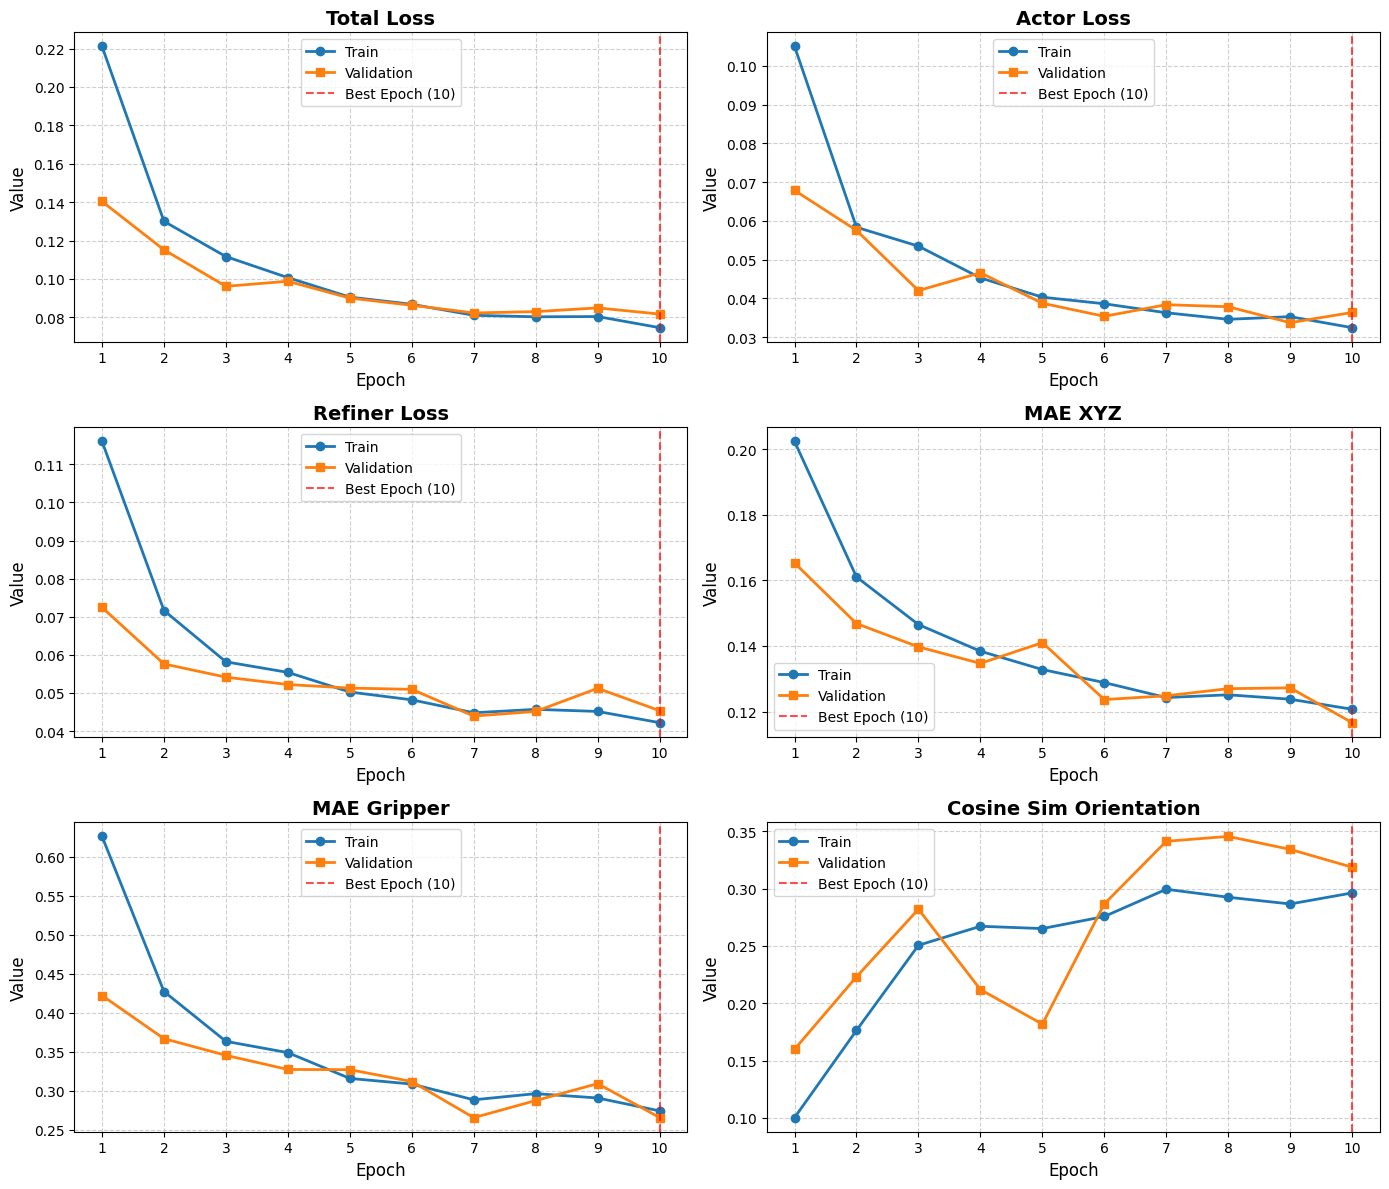

In [8]:
results_path = './results/2026_04_05__00_34'
config_filename = 'experiment_config.json'

import matplotlib.pyplot as plt

with open(os.path.join(results_path, config_filename), 'r') as f:
        data = json.load(f)

# 2. Estrai il numero totale di epoche e la best epoch
num_epochs = data['hyperparameters']['num_epochs']
epochs = range(1, num_epochs + 1)
best_epoch = data['best_epoch']

# Definisci le chiavi delle metriche da cercare nel JSON e i titoli per i grafici
metrics_keys = ['loss', 'loss_actor', 'loss_refiner', 'mae_xyz', 'mae_gripper', 'cosim_ori']
titles = ['Total Loss', 'Actor Loss', 'Refiner Loss', 'MAE XYZ', 'MAE Gripper', 'Cosine Sim Orientation']

# 3. Crea una griglia 3x2 per contenere tutti e 6 i grafici
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten() # Trasforma la matrice 3x2 in una lista piatta per iterare facilmente

# 4. Disegna ogni grafico
for i, metric in enumerate(metrics_keys):
    # Estrai le liste dei valori per train e validation
    train_vals = [epoch[metric] for epoch in data['history']['train']]
    val_vals = [epoch[metric] for epoch in data['history']['validation']]
    
    ax = axes[i]
    
    # Plotta le curve
    ax.plot(epochs, train_vals, label='Train', marker='o', linewidth=2)
    ax.plot(epochs, val_vals, label='Validation', marker='s', linewidth=2)
    
    # Linea verticale rossa per indicare l'epoca migliore
    ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    
    # Estetica: titoli, etichette, griglia e legenda
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xticks(epochs) # Mostra tutti i numeri delle epoche sull'asse X
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

# 5. Ottimizza gli spazi tra i grafici in modo che i testi non si sovrappongano
plt.tight_layout()